# Perception fromage — cheese factory (Isaac Sim)

Brique de perception du défi : **une image de caméra entre, un label de tri sort**,
le pipeline aval s'en sert pour commander le bras.

```
caméra Isaac Sim ──▶ CheeseClassifier.predict(frame) ──▶ Prediction(label, confidence) ──▶ contrôle robot
```

Cette feuille couvre : l'état des données normalisées, le piège de fuite dans
CHEESE-HIDB, les performances des modèles, et l'appel d'inférence tel qu'il sera
fait depuis la sim.

**La vidéo est en section 8** : le modèle qui aiguille une ligne de tri complète dans
Isaac Sim, une voie de sortie par classe.

> La feuille est **exécutable telle quelle** dans cette webapp : le kernel `python3`
> voit les deux H100 et le projet est copié sous `/workspace/cheese`. Elle tourne
> aussi sur l'hôte (`/home/nvidia/hpe/cheese`) — la première cellule détecte le
> chemin toute seule.

In [1]:
import sys, json, collections, warnings
from pathlib import Path

# la feuille tourne soit sur l'hote, soit dans le conteneur jupyter ou le projet
# est copie sous /workspace : on prend le premier chemin qui existe
PROJET = next(p for p in (Path('/home/nvidia/hpe/cheese'), Path('/workspace/cheese'))
              if p.exists())
print('projet      ', PROJET)
sys.path.insert(0, str(PROJET / 'src'))
warnings.filterwarnings('ignore')

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

print('python     ', sys.version.split()[0])
print('torch      ', torch.__version__, '| cuda', torch.cuda.is_available())
for i in range(torch.cuda.device_count()):
    print(f'  gpu {i}      ', torch.cuda.get_device_name(i))

projet       /home/nvidia/hpe/cheese


python      3.12.3
torch       2.6.0+cu124 | cuda True
  gpu 0       NVIDIA H100 NVL
  gpu 1       NVIDIA H100 NVL


## 1. Les données normalisées

Trois sources hétérogènes ramenées à un format unique par `src/normalize.py` :
JPEG RGB, grand côté 512, EXIF redressé, dédoublonné, et un manifeste CSV unique.

In [2]:
from dataset import load_manifest, build_label_space, TASKS

rows = load_manifest()
stats = json.loads((PROJET / 'data/processed/stats.json').read_text())

print(f"{len(rows)} images normalisées\n")
for src, info in stats['per_source'].items():
    sp = info['splits']
    print(f"{src:18s} {info['images']:5d} img  {info['classes']:4d} classes  "
          f"train/val/test = {sp.get('train',0)}/{sp.get('val',0)}/{sp.get('test',0)}")

cs = stats['channel_stats']
print(f"\nnormalisation (calculée sur le train seul)")
print(f"  mean {cs['mean']}")
print(f"  std  {cs['std']}")

6486 images normalisées

cheese_hidb          378 img     6 classes  train/val/test = 128/126/124
cheese_images       3211 img   288 classes  train/val/test = 2257/477/477
food_recognition    2897 img    12 classes  train/val/test = 2041/433/423

normalisation (calculée sur le train seul)
  mean [0.57893, 0.5269, 0.45318]
  std  [0.27042, 0.26677, 0.27936]


### Les tâches disponibles

Les trois jeux ont des espaces d'étiquettes **incompatibles** : on ne les fusionne
pas de force, on expose plusieurs têtes. Celle qui compte pour le robot est `bin`.

In [3]:
for t in sorted(TASKS):
    sub, c2i, col = build_label_space(rows, t)
    sp = collections.Counter(r['split'] for r in sub)
    print(f"{t:24s} {len(c2i):4d} classes  {len(sub):5d} img  "
          f"tr/va/te = {sp['train']}/{sp['val']}/{sp['test']}")

all                       306 classes   6486 img  tr/va/te = 4426/1036/1024
bin                         5 classes   2088 img  tr/va/te = 1473/311/304
fr_cheese_type             12 classes   2897 img  tr/va/te = 2041/433/423
hidb_product                3 classes    378 img  tr/va/te = 128/126/124
hidb_product_ripeness       6 classes    378 img  tr/va/te = 128/126/124
hidb_ripeness               2 classes    378 img  tr/va/te = 128/126/124
sim_bin                     0 classes      0 img  tr/va/te = 0/0/0
texture                     5 classes   2466 img  tr/va/te = 1601/437/428
variety                   288 classes   3211 img  tr/va/te = 2257/477/477


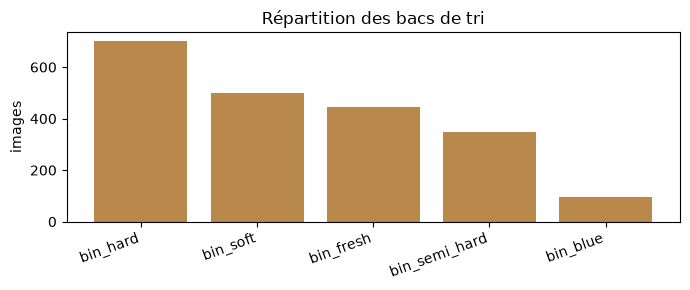

déséquilibre max/min : 7.446808510638298


In [4]:
# Les 5 bacs de tri : c'est le label envoyé au bras
sub, bins, _ = build_label_space(rows, 'bin')
compte = collections.Counter(r['bin'] for r in sub)

fig, ax = plt.subplots(figsize=(7, 3))
noms = sorted(compte, key=compte.get, reverse=True)
ax.bar(noms, [compte[n] for n in noms], color='#b8894a')
ax.set_ylabel('images'); ax.set_title('Répartition des bacs de tri')
plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()

print('déséquilibre max/min :', max(compte.values()) / min(compte.values()))

### À quoi ressemblent les données

Important pour la suite : les instances de Food Recognition sont des **découpes**
de scènes de repas (fromage dans une assiette, sur du pain, dans une main), pas
des pièces isolées sur un tapis.

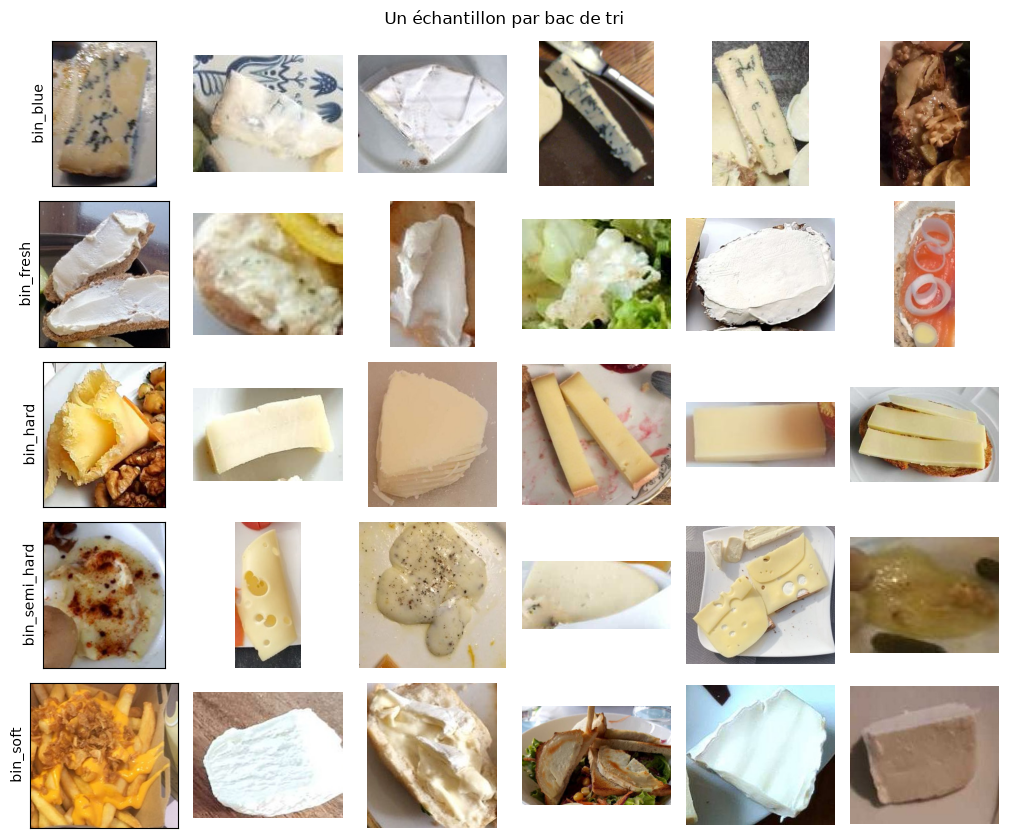

In [5]:
def planche(lignes, par_ligne=6, taille=1.7, titre=None):
    fig, axes = plt.subplots(len(lignes), par_ligne,
                             figsize=(par_ligne * taille, len(lignes) * taille))
    axes = np.atleast_2d(axes)
    for ax in axes.ravel():
        ax.axis('off')
    for y, (nom, items) in enumerate(lignes):
        for x, r in enumerate(items[:par_ligne]):
            with Image.open(PROJET / 'data/processed' / r['path']) as im:
                axes[y, x].imshow(im.convert('RGB'))
        axes[y, 0].set_ylabel(nom)
        axes[y, 0].axis('on')
        axes[y, 0].set_xticks([]); axes[y, 0].set_yticks([])
    if titre:
        fig.suptitle(titre)
    plt.tight_layout(); plt.show()

import random
random.seed(0)
par_bac = collections.defaultdict(list)
for r in sub:
    par_bac[r['bin']].append(r)
planche([(b, random.sample(par_bac[b], 6)) for b in sorted(par_bac)],
        titre='Un échantillon par bac de tri')

## 2. Le piège : CHEESE-HIDB ne contient que 9 meules

Les 378 images de CHEESE-HIDB ne sont pas 378 fromages. Ce sont **9 meules**,
chacune photographiée 42 fois sur un plateau tournant — des blocs de numéros DSC
consécutifs, exactement 42 par bloc.

Un split par image met la même meule dans train **et** dans test. Le modèle mémorise
la meule au lieu d'apprendre le fromage : le premier essai affichait **100 % de
macro-F1 dès l'époque 13**, un chiffre sans aucune valeur prédictive.

La colonne `group` du manifeste est donc la meule, et les splits la respectent.

In [6]:
import re
hidb = [r for r in rows if r['source'] == 'cheese_hidb']

blocs = collections.defaultdict(list)
for r in hidb:
    blocs[r['label']].append(int(re.search(r'(\d+)', Path(r['src_path']).stem).group(1)))

for label in sorted(blocs):
    ns = sorted(blocs[label]); segments = []; debut = prec = ns[0]
    for n in ns[1:]:
        if n - prec > 1:
            segments.append((debut, prec)); debut = n
        prec = n
    segments.append((debut, prec))
    print(f"{label:24s} {len(ns):3d} img = " +
          '  '.join(f'{a}-{b} ({b - a + 1} vues)' for a, b in segments))

extra_hard__nottarget     84 img = 1771-1812 (42 vues)  1814-1855 (42 vues)
extra_hard__target        42 img = 1900-1941 (42 vues)
hard__nottarget           84 img = 1943-1984 (42 vues)  1986-2027 (42 vues)
hard__target              42 img = 1857-1898 (42 vues)
semi_hard__nottarget      84 img = 2029-2070 (42 vues)  2072-2113 (42 vues)
semi_hard__target         42 img = 1727-1766 (40 vues)  1768-1769 (2 vues)


In [7]:
meules = collections.defaultdict(set)
for r in hidb:
    meules[r['group']].add(r['split'])

print(f'{len(meules)} meules identifiées\n')
for m in sorted(meules):
    print(f'  {m:34s} -> {sorted(meules[m])[0]}')
print('\nmeules à cheval sur deux splits :',
      sum(1 for v in meules.values() if len(v) > 1))

10 meules identifiées

  extra_hard__nottarget#wheel0       -> test
  extra_hard__nottarget#wheel1       -> train
  extra_hard__target#wheel0          -> val
  hard__nottarget#wheel0             -> val
  hard__nottarget#wheel1             -> train
  hard__target#wheel0                -> test
  semi_hard__nottarget#wheel0        -> train
  semi_hard__nottarget#wheel1        -> val
  semi_hard__target#wheel0           -> test
  semi_hard__target#wheel1           -> train

meules à cheval sur deux splits : 0


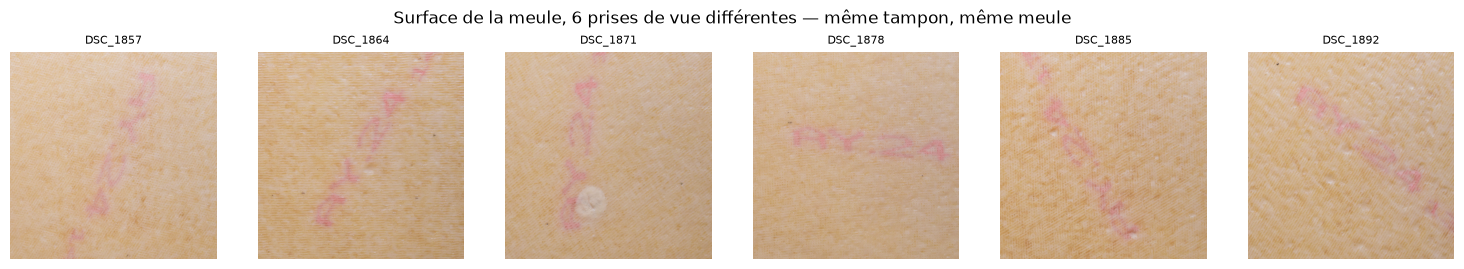

In [8]:
# La preuve visuelle : 6 vues de hard__target, le même tampon d'encre rose tourne
cible = sorted([r for r in hidb if r['label'] == 'hard__target'],
               key=lambda r: r['src_path'])[::7][:6]
fig, axes = plt.subplots(1, 6, figsize=(15, 2.7))
for ax, r in zip(axes, cible):
    with Image.open(PROJET / r['src_path']) as im:
        w, h = im.size
        ax.imshow(im.crop((w//2 - 700, h//2 - 700, w//2 + 700, h//2 + 700)))
    ax.set_title(Path(r['src_path']).stem, fontsize=8); ax.axis('off')
fig.suptitle('Surface de la meule, 6 prises de vue différentes — même tampon, même meule')
plt.tight_layout(); plt.show()

**Conséquence directe sur ce qui est mesurable :**

| tâche | meules par classe | verdict |
|---|---|---|
| `hidb_product_ripeness` (6 cl.) | 1 à 2 | pas évaluable, tout part en train |
| `hidb_product` (3 cl.) | 3 à 4 | split par meule tenable → **la seule mesurable** |

L'autre usage de HIDB, sans doute le plus payant ici : 42 vues à 360° d'une meule,
c'est du matériau de photogrammétrie pour texturer l'asset 3D du tapis dans Omniverse.

## 3. Ce que valent les modèles

ConvNeXt-Base pré-entraîné ImageNet-22k, 384 px, AdamW + cosine, bf16.
Le checkpoint retenu est celui du meilleur **macro-F1 de validation** — pas
l'accuracy, qui se laisse porter par les classes majoritaires.

In [9]:
resultats = {}
for d in sorted((PROJET / 'runs').glob('*/results.json')):
    resultats[d.parent.name] = json.loads(d.read_text())

if not resultats:
    print("aucun run trouvé — lancer src/train.py d'abord")
else:
    print(f"{'tâche':22s} {'cl.':>4s} {'top-1':>8s} {'top-5':>8s} {'macro-F1':>9s}")
    print('-' * 56)
    for nom, r in resultats.items():
        t = r.get('test')
        n = len(build_label_space(rows, nom)[1]) if nom in TASKS else 0
        if t:
            print(f"{nom:22s} {n:4d} {t['top1']:8.3f} {t['top5']:8.3f} {t['macro_f1']:9.3f}")
        else:
            b = r['best_val']
            print(f"{nom:22s} {n:4d} {'—':>8s} {'—':>8s} {b['macro_f1']:9.3f}  (val)")

tâche                   cl.    top-1    top-5  macro-F1
--------------------------------------------------------
bin                       5    0.789    1.000     0.767
fr_cheese_type           12    0.591    0.903     0.499
hidb_product              3    0.758    1.000     0.727
sim_bin                   0    0.763    1.000     0.709
variety                 288    0.524    0.704     0.353


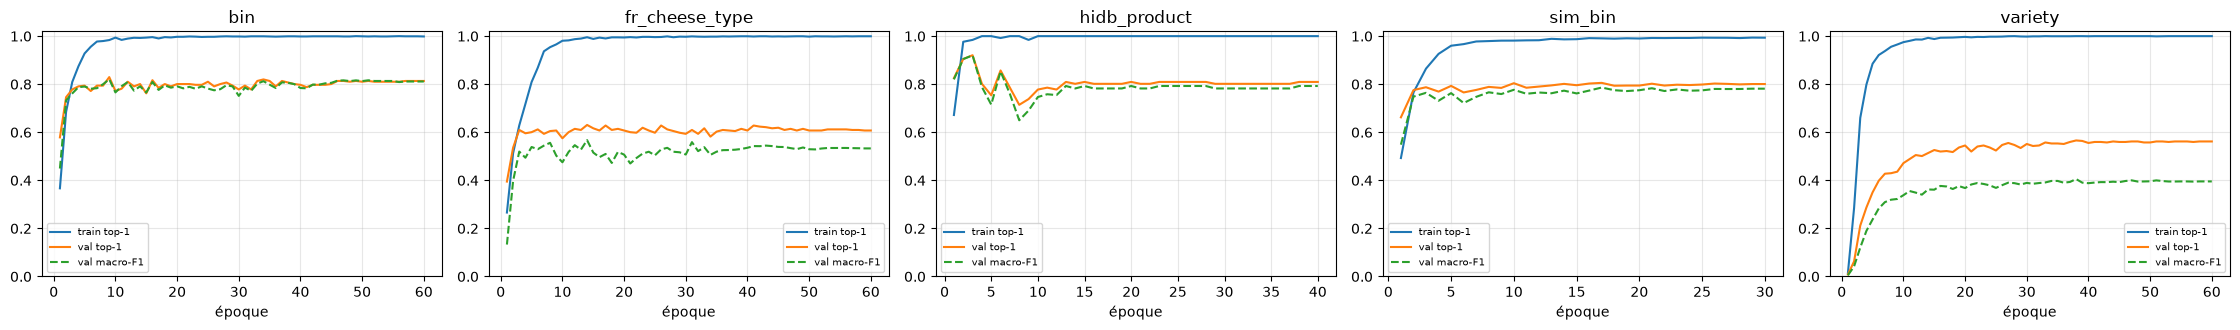

In [10]:
# Courbes d'apprentissage
if resultats:
    fig, axes = plt.subplots(1, len(resultats), figsize=(4.5 * len(resultats), 3.4), squeeze=False)
    for ax, (nom, r) in zip(axes[0], resultats.items()):
        h = r['history']
        ep = [e['epoch'] for e in h]
        ax.plot(ep, [e['train_top1'] for e in h], label='train top-1')
        ax.plot(ep, [e['val_top1'] for e in h], label='val top-1')
        ax.plot(ep, [e['val_macro_f1'] for e in h], label='val macro-F1', ls='--')
        ax.set_title(nom); ax.set_xlabel('époque'); ax.set_ylim(0, 1.02)
        ax.grid(alpha=.3); ax.legend(fontsize=7)
    plt.tight_layout(); plt.show()

In [11]:
# Où le modèle de tri se trompe
from sklearn.metrics import confusion_matrix

if 'bin' in resultats and 'per_class' in resultats['bin']:
    pc = resultats['bin']['per_class']
    classes = [c for c in pc if c not in ('accuracy', 'macro avg', 'weighted avg')]
    print(f"{'bac':18s} {'précision':>10s} {'rappel':>8s} {'F1':>7s} {'support':>8s}")
    print('-' * 55)
    for c in sorted(classes, key=lambda c: -pc[c]['support']):
        m = pc[c]
        print(f"{c:18s} {m['precision']:10.3f} {m['recall']:8.3f} "
              f"{m['f1-score']:7.3f} {int(m['support']):8d}")

bac                 précision   rappel      F1  support
-------------------------------------------------------
bin_hard                0.837    0.897   0.866       97
bin_soft                0.778    0.671   0.721       73
bin_fresh               0.855    0.768   0.809       69
bin_semi_hard           0.696    0.780   0.736       50
bin_blue                0.632    0.800   0.706       15


## 4. L'appel d'inférence, tel qu'il sera fait depuis la sim

C'est le contrat que consomme le pipeline de contrôle du bras.

In [12]:
from predict import CheeseClassifier

ckpt = PROJET / 'runs/bin/best.pt'
clf = CheeseClassifier(ckpt, min_confidence=0.55)
clf.warmup()
print(f'tâche {clf.task} | {len(clf.classes)} classes | entrée {clf.img_size} px')
print('bacs :', clf.classes)

tâche bin | 5 classes | entrée 384 px
bacs : ['bin_blue', 'bin_fresh', 'bin_hard', 'bin_semi_hard', 'bin_soft']


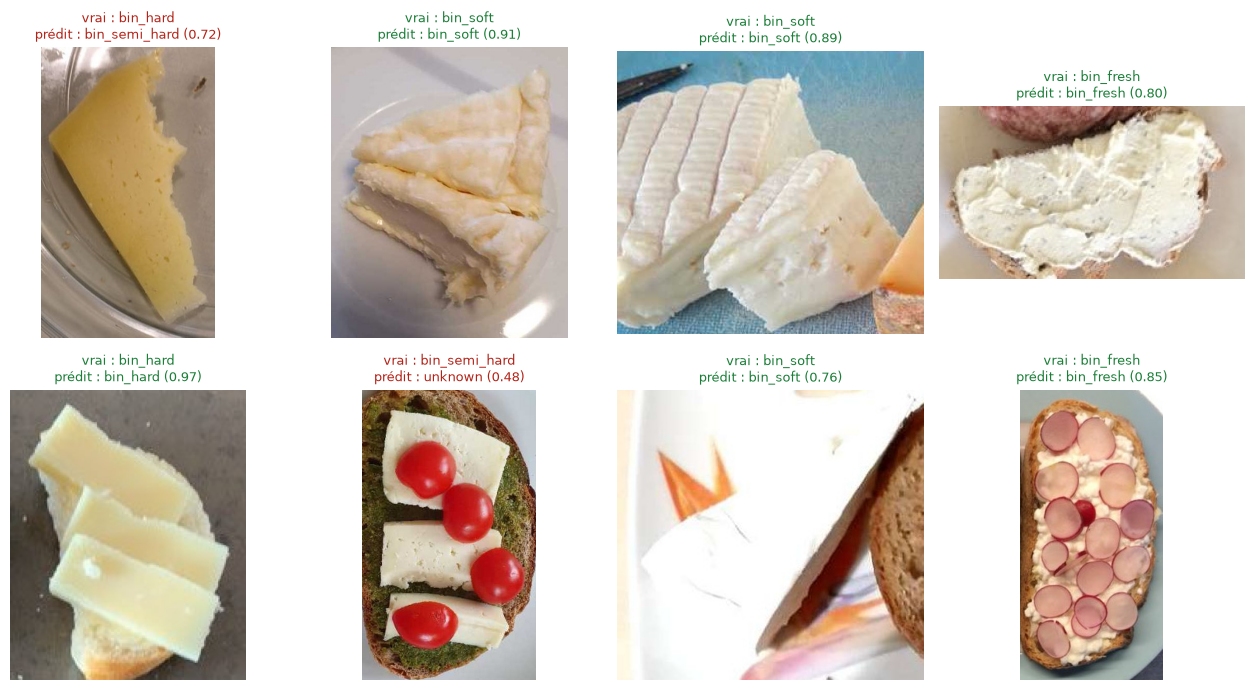

In [13]:
# Sur quelques images de test jamais vues
test = [r for r in sub if r['split'] == 'test']
random.seed(3)
echantillon = random.sample(test, 8)

fig, axes = plt.subplots(2, 4, figsize=(13, 7))
for ax, r in zip(axes.ravel(), echantillon):
    with Image.open(PROJET / 'data/processed' / r['path']) as im:
        im = im.convert('RGB')
        pred = clf.predict(im)
        ax.imshow(im)
    juste = pred.label == r['bin']
    ax.set_title(f"vrai : {r['bin']}\nprédit : {pred.label} ({pred.confidence:.2f})",
                 fontsize=9, color='#1a7f37' if juste else '#b42318')
    ax.axis('off')
plt.tight_layout(); plt.show()

### Le seuil de confiance, et pourquoi il compte

Sous `min_confidence`, le label vaut `"unknown"` : **le bras doit laisser passer la
pièce** plutôt que la ranger au hasard. Un mauvais rangement coûte plus cher qu'un
non-rangement, donc ce seuil se règle sur ce compromis-là, pas sur l'accuracy.

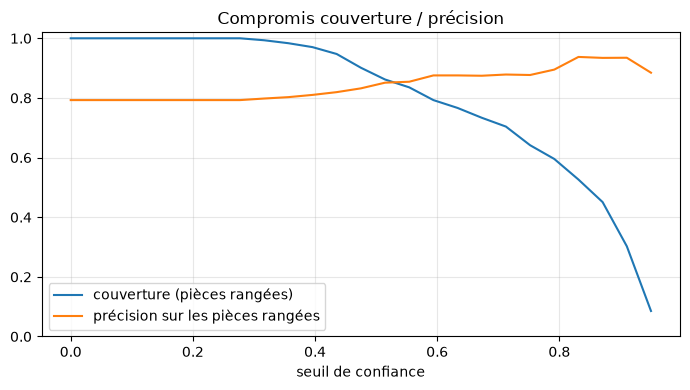

seuil 0.0 : 100.0% des pièces rangées, 79.3% correctement
seuil 0.5 : 87.8% des pièces rangées, 84.6% correctement
seuil 0.7 : 71.7% des pièces rangées, 87.2% correctement
seuil 0.9 : 32.9% des pièces rangées, 93.0% correctement


In [14]:
lots = [test[i:i+64] for i in range(0, len(test), 64)]
pred_labels, confs, vrais = [], [], []
for lot in lots:
    images = [Image.open(PROJET / 'data/processed' / r['path']).convert('RGB') for r in lot]
    for p, r in zip(clf.predict_batch(None, frames=images), lot):
        pred_labels.append(p.topk[0][0]); confs.append(p.topk[0][1]); vrais.append(r['bin'])
    for im in images:
        im.close()

confs = np.array(confs)
justes = np.array([p == v for p, v in zip(pred_labels, vrais)])

seuils = np.linspace(0, 0.95, 25)
couverture = [(confs >= s).mean() for s in seuils]
precision = [justes[confs >= s].mean() if (confs >= s).any() else np.nan for s in seuils]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(seuils, couverture, label='couverture (pièces rangées)')
ax.plot(seuils, precision, label='précision sur les pièces rangées')
ax.set_xlabel('seuil de confiance'); ax.set_ylim(0, 1.02)
ax.grid(alpha=.3); ax.legend(); ax.set_title('Compromis couverture / précision')
plt.tight_layout(); plt.show()

for s in (0.0, 0.5, 0.7, 0.9):
    m = confs >= s
    print(f'seuil {s:.1f} : {m.mean():5.1%} des pièces rangées, '
          f'{justes[m].mean():5.1%} correctement' if m.any() else f'seuil {s}: aucune')

### Latence — est-ce que ça tient la cadence du tapis ?

In [15]:
dummy = np.random.randint(0, 255, (720, 1280, 3), dtype=np.uint8)
clf.warmup(5)

import time
for n in (1, 4, 8):
    boites = [(100 + 60*i, 100, 400 + 60*i, 400) for i in range(n)]
    t0 = time.perf_counter()
    for _ in range(20):
        clf.predict_batch(dummy, boxes=boites)
    dt = (time.perf_counter() - t0) / 20
    print(f'{n} pièce(s) par frame : {dt*1e3:6.1f} ms  ->  {1/dt:5.1f} frames/s')

1 pièce(s) par frame :   14.0 ms  ->   71.2 frames/s


4 pièce(s) par frame :   30.8 ms  ->   32.4 frames/s


8 pièce(s) par frame :   52.4 ms  ->   19.1 frames/s


## 5. Ce qui reste à faire côté sim

Les modèles sont entraînés sur des **photos réelles**. La caméra d'Isaac Sim rendra
des pièces sur un tapis, éclairage synthétique, fond uniforme. Cet écart de domaine
est réel et **aucun chiffre de cette feuille ne le mesure**. La section 8 fait passer
au modèle des images d'une scène Isaac Sim vivante, mais sur onze pièces choisies :
elle sonde l'écart, elle ne le mesure pas.

Trois leviers, par ordre d'efficacité :

1. capturer quelques centaines de frames rendues dans la sim, les étiqueter, et faire
   un fine-tuning court — c'est ce qui rattrape le plus d'écart ;
2. randomisation de domaine côté Omniverse : lumière, textures, poses, fond ;
3. l'augmentation à l'entraînement est déjà agressive, mais elle ne remplace pas les
   deux premiers points.

Pour l'intégration, `src/export.py` sort un ONNX + un `_sidecar.json` (ordre des
classes, taille d'entrée, prétraitement exact) si tu préfères passer par TensorRT
plutôt que par le runtime PyTorch.

## 6. Avant / après — de la photo réelle au rendu Isaac Sim

Les modèles de la section 3 sont entraînés sur des **photos réelles** : du fromage
dans une assiette, sur une planche, tenu à la main. La caméra du tapis verra tout
autre chose. Cette section transforme les photos en rendus de la scène cible, pour
que l'entraînement et l'inférence partagent le même domaine.

La chaîne comporte trois étapes :

| étape | ce qu'on obtient |
|---|---|
| découpe du polygone (`src/cutouts.py`) | une pièce RGBA à **silhouette réelle**, sans le fond rectangulaire |
| scène USD (`sim/render_belt.py`) | tapis, longerons, lattes, assiette, éclairage, caméra |
| rendu multi-vues | N vues par pièce, avec randomisation de domaine |

### Étape 1 — la découpe

Les images normalisées sont des **rectangles** : le fromage plus le pain, l'assiette
ou la main qui l'entourent. Les poser telles quelles dans une assiette donnerait « une
photo posée dans une assiette ». Food Recognition annote chaque instance par un
polygone : on s'en sert comme canal alpha, et le contour devient celui du fromage.

In [16]:
import csv

decoupes = list(csv.DictReader(open(PROJET / 'data/processed/cutouts/manifest.csv')))
par_bac = collections.defaultdict(list)
for d in decoupes:
    par_bac[d['bin']].append(d)

print(f'{len(decoupes)} découpes RGBA')
for b in sorted(par_bac):
    print(f'  {b:16s} {len(par_bac[b]):4d}')

2000 découpes RGBA
  bin_blue           92
  bin_fresh         417
  bin_hard          678
  bin_semi_hard     338
  bin_soft          475


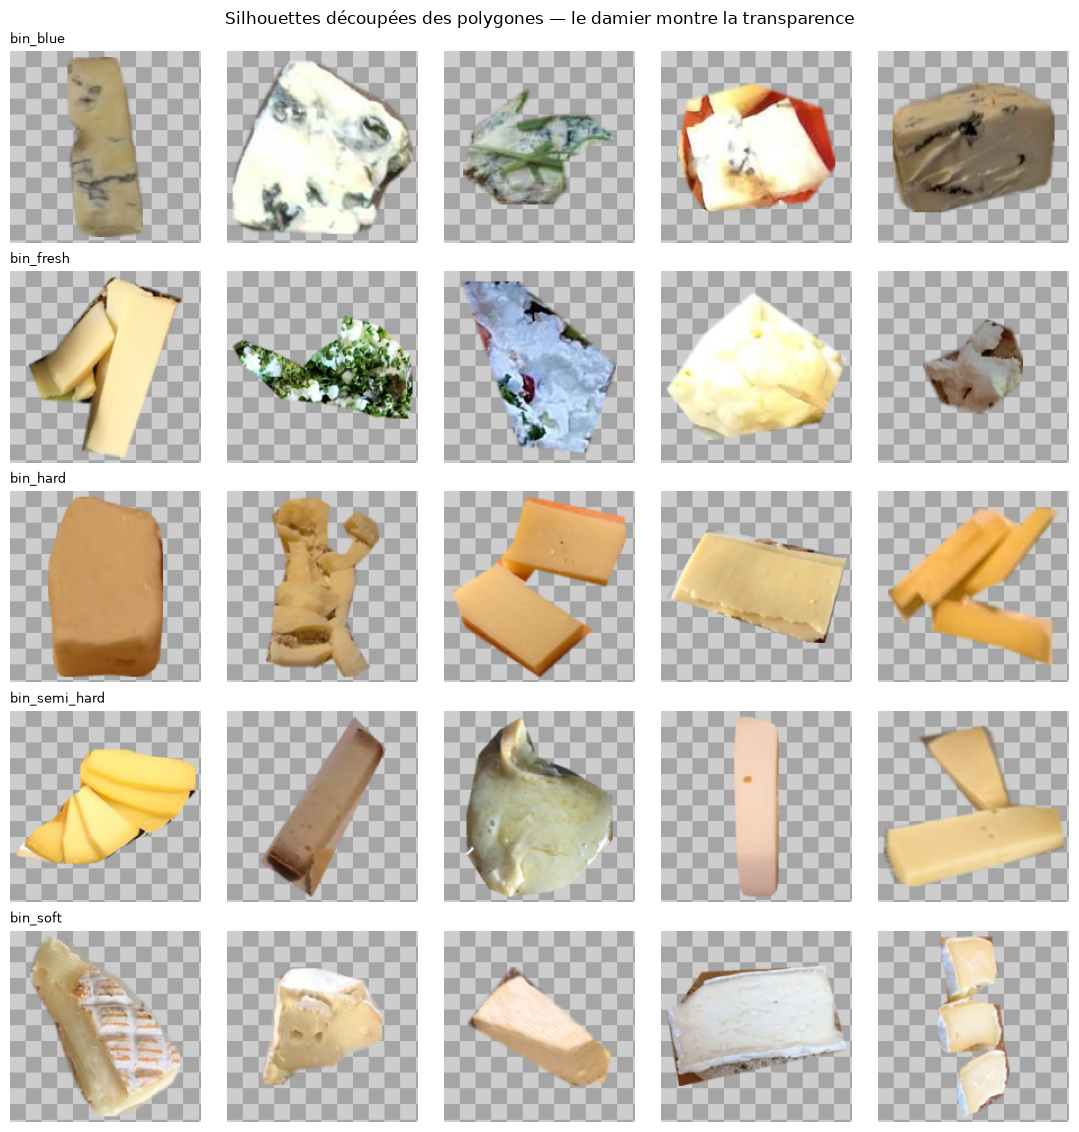

In [17]:
# damier pour rendre l'alpha visible
def sur_damier(im, T=170, pas=14):
    fond = Image.new('RGB', (T, T), (205, 205, 205))
    for y in range(0, T, pas):
        for x in range(0, T, pas):
            if (x // pas + y // pas) % 2:
                fond.paste((165, 165, 165), (x, y, x + pas, y + pas))
    im = im.convert('RGBA').copy()
    im.thumbnail((T - 10, T - 10))
    fond.paste(im, ((T - im.width) // 2, (T - im.height) // 2), im)
    return fond

random.seed(5)
bacs = sorted(par_bac)
fig, axes = plt.subplots(len(bacs), 5, figsize=(11, 2.3 * len(bacs)))
for y, b in enumerate(bacs):
    for x, d in enumerate(random.sample(par_bac[b], 5)):
        with Image.open(PROJET / 'data/processed' / d['path']) as im:
            axes[y, x].imshow(sur_damier(im))
        axes[y, x].axis('off')
    axes[y, 0].set_title(b, loc='left', fontsize=9)
fig.suptitle('Silhouettes découpées des polygones — le damier montre la transparence')
plt.tight_layout(); plt.show()

### Étape 2 et 3 — la scène et les rendus

La pièce est appliquée sur un quad posé au fond de l'assiette, avec l'alpha en seuil
de découpe (`UsdPreviewSurface.opacityThreshold`). À chaque vue, on tire au hasard :
rotation et position de la pièce, azimut / élévation / distance / focale de la caméra,
position, intensité et teinte de la lampe, intensité du dôme, et les teintes de
l'assiette et du tapis.

L'assiette est un **maillage à 96 segments** et non un cylindre USD : la tessellation
par défaut donnait un décagone, une arête franche que le modèle aurait apprise comme
indice de fond plutôt que comme du fromage.

9545 rendus, 1909 pièces distinctes


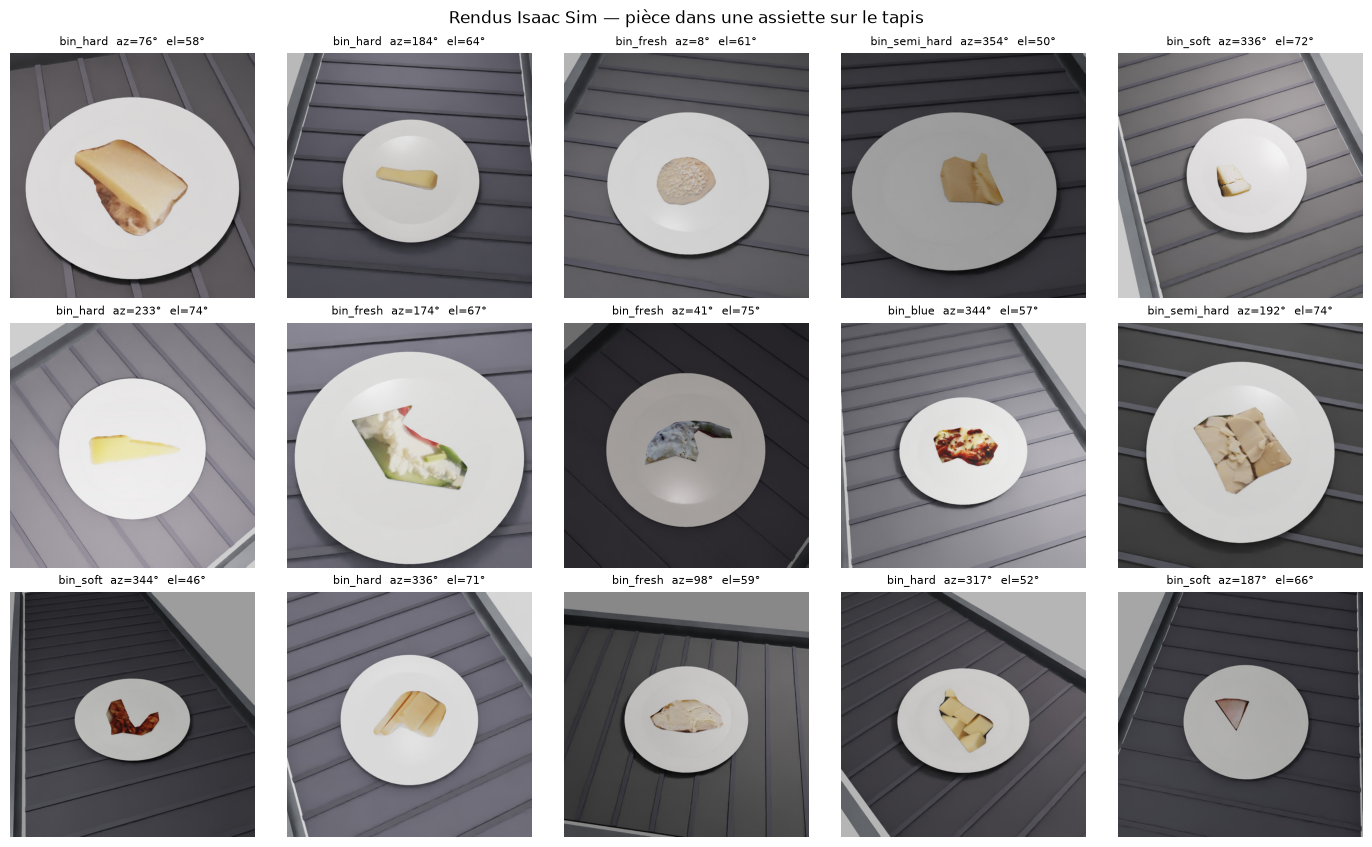

In [18]:
# le manifeste final : images converties en JPEG 512, splits par pièce
sim_rows = load_manifest(PROJET / 'data/processed/manifest_sim.csv')
rendus = [{'file': r['path'], 'bin': r['label'], 'group': r['group'],
           'view': json.loads(r['extra'])['view'],
           'azimut': json.loads(r['extra'])['azimut'],
           'elevation': json.loads(r['extra'])['elevation']} for r in sim_rows]
print(f"{len(rendus)} rendus, {len({r['group'] for r in rendus})} pièces distinctes")

random.seed(4)
fig, axes = plt.subplots(3, 5, figsize=(14, 8.6))
for ax, r in zip(axes.ravel(), random.sample(rendus, 15)):
    with Image.open(PROJET / 'data/processed' / r['file']) as im:
        ax.imshow(im.convert('RGB'))
    ax.set_title(f"{r['bin']}  az={r['azimut']:.0f}°  el={r['elevation']:.0f}°", fontsize=8)
    ax.axis('off')
fig.suptitle('Rendus Isaac Sim — pièce dans une assiette sur le tapis')
plt.tight_layout(); plt.show()

### La comparaison, pièce par pièce

Chaque ligne suit **la même pièce** : la photo d'origine, sa silhouette découpée,
puis trois rendus sous des angles et des éclairages différents.

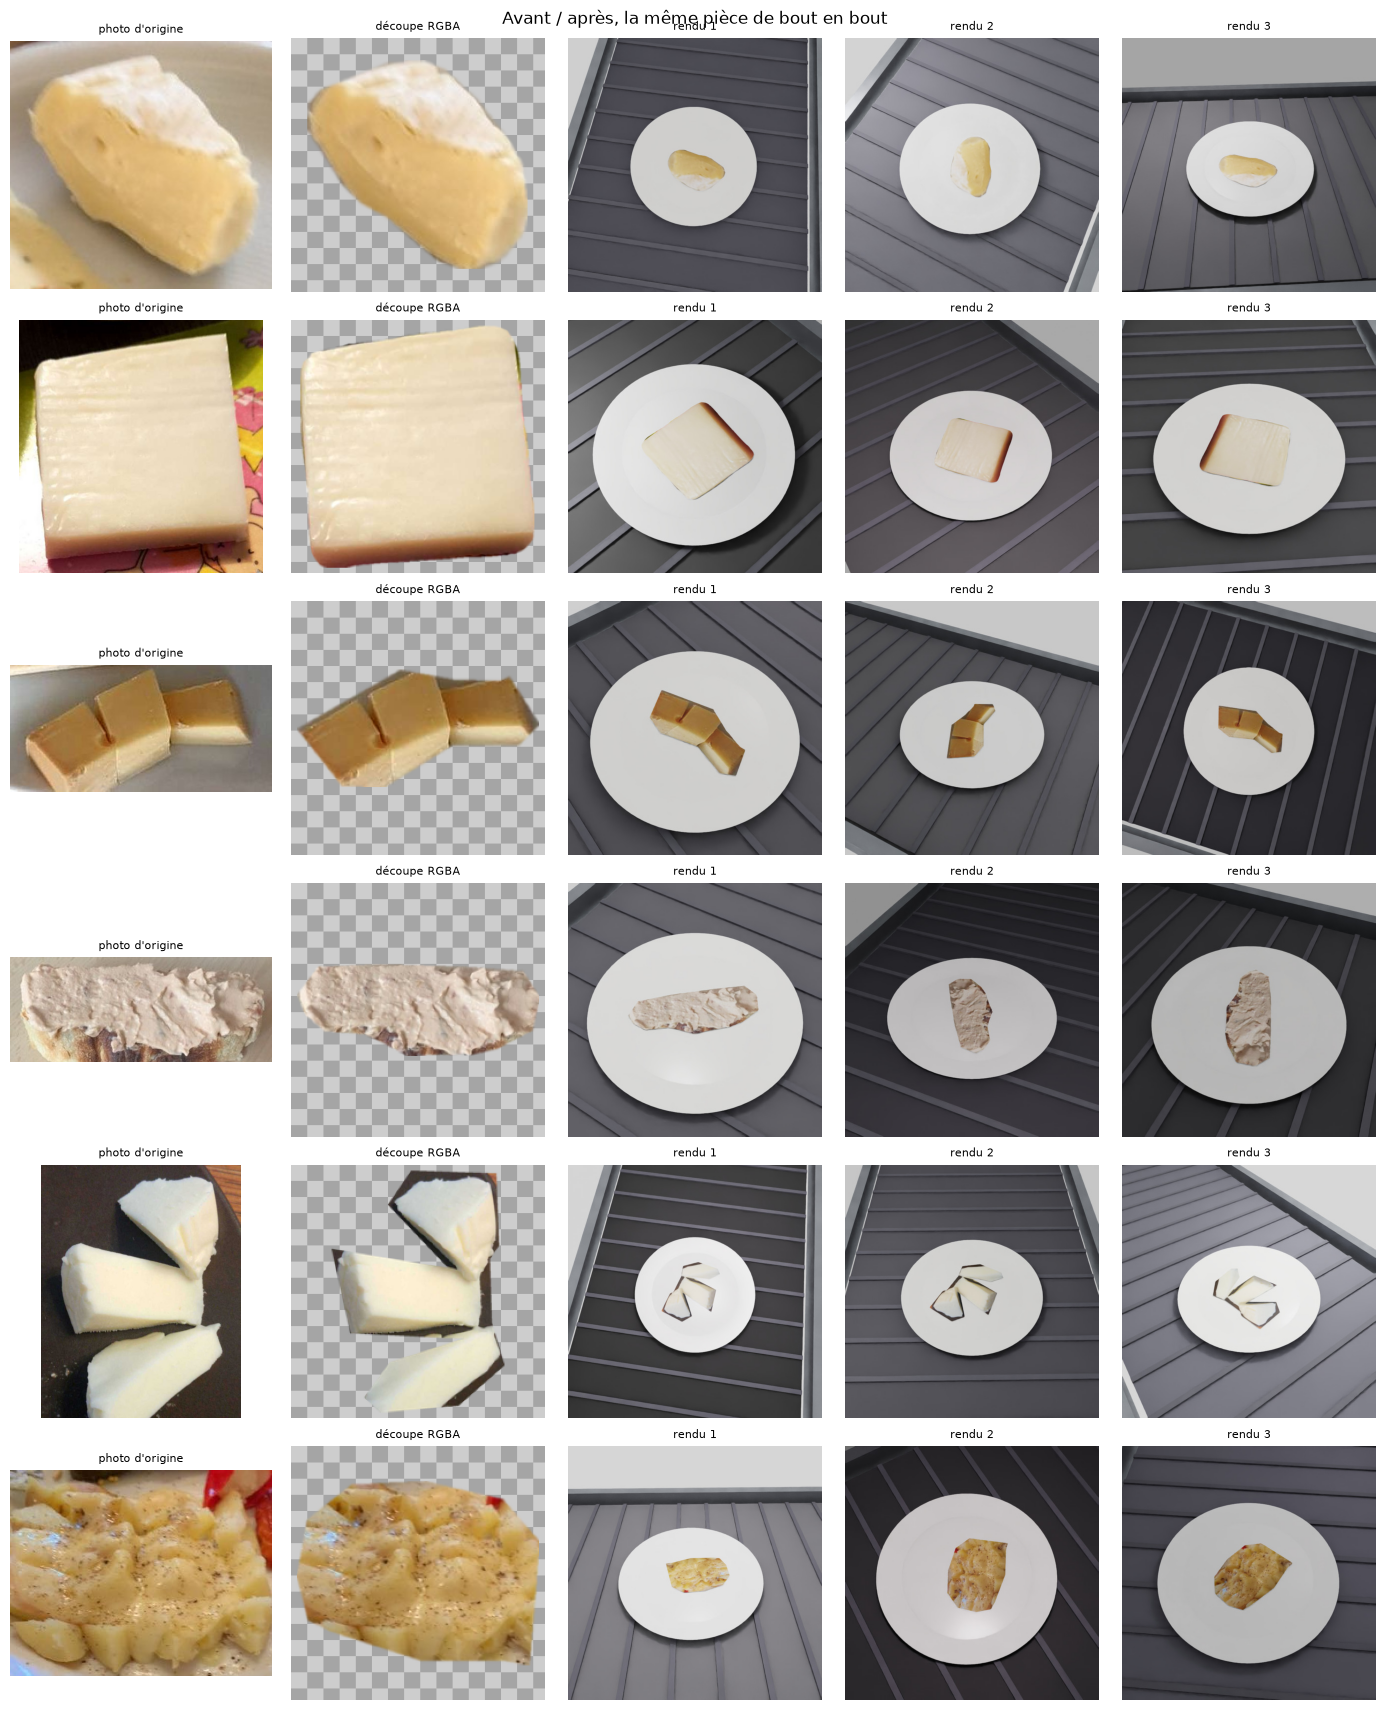

In [19]:
manif = {r['uid']: r for r in rows}
cut = {d['uid']: d for d in decoupes}
par_piece = collections.defaultdict(list)
for r in rendus:
    par_piece[r['group']].append(r)

random.seed(8)
candidates = [u for u in par_piece if u in manif and u in cut]
pieces = random.sample(candidates, 6)
fig, axes = plt.subplots(len(pieces), 5, figsize=(14, 2.9 * len(pieces)))
for y, uid in enumerate(pieces):
    with Image.open(PROJET / 'data/processed' / manif[uid]['path']) as im:
        axes[y, 0].imshow(im.convert('RGB'))
    axes[y, 0].set_title("photo d'origine", fontsize=8)
    with Image.open(PROJET / 'data/processed' / cut[uid]['path']) as im:
        axes[y, 1].imshow(sur_damier(im, T=220))
    axes[y, 1].set_title('découpe RGBA', fontsize=8)
    for x, r in enumerate(sorted(par_piece[uid], key=lambda r: r['view'])[:3]):
        with Image.open(PROJET / 'data/processed' / r['file']) as im:
            axes[y, 2 + x].imshow(im.convert('RGB'))
        axes[y, 2 + x].set_title(f'rendu {x + 1}', fontsize=8)
    for ax in axes[y]:
        ax.axis('off')
fig.suptitle('Avant / après, la même pièce de bout en bout')
plt.tight_layout(); plt.show()

### Deux choses à ne pas perdre de vue

**La pièce reste plate.** C'est une décalcomanie à silhouette juste, pas un volume :
ni épaisseur, ni auto-ombrage, ni reflet propre à une pâte grasse. L'ombrage visible
vient de la photo d'origine. Si la scène de démo pose de vrais assets 3D sur le tapis,
l'écart se déplace au lieu de disparaître.

**Les vues d'une même pièce sont corrélées.** Trois vues du même fromage ne sont pas
trois échantillons : c'est le même objet sous trois angles. Si elles se répartissent
entre train et test, on remesure la fuite qu'on a corrigée sur les meules CHEESE-HIDB
en section 2. Le champ `group` du manifeste des rendus porte l'uid de la pièce source
— c'est lui qui doit piloter le découpage, pas le nom de fichier.

Et un rappel arithmétique : multiplier les angles **n'ajoute aucun fromage**. On aura
toujours 2 000 pièces distinctes, vues sous plus d'angles. Cela aide le modèle à
devenir invariant au point de vue ; cela ne lui apprend pas de nouvelles variétés.

### Ce que le score sur rendus mesure — et ce qu'il ne mesure pas

À lire avant de citer le chiffre de `sim_bin` quelque part.

**Ce qu'il mesure :** la capacité à classer ces 1 909 pièces sources vues sous des
angles, des éclairages et des cadrages variés. C'est une vraie mesure d'**invariance
au point de vue**, et les splits sont propres — les 5 vues d'une pièce restent du
même côté de la frontière.

**Ce qu'il ne mesure pas :** la performance sur la scène de démo. Train et test
partagent les mêmes photos sources, le même moteur de rendu, la même assiette, le
même tapis, et la même approximation — des décalcomanies plates, pas des volumes.
Un score élevé ici ne dit rien de plus sur le tapis réel que le `bin` entraîné sur
photos.

**Trois biais connus, par ordre de gravité :**

1. **L'éclairage est cuit dans la photo.** Chaque découpe porte l'éclairage de sa
   prise de vue d'origine — flash, fenêtre, néon — qui se superpose à celui de la
   scène. Pire, ce style photographique est corrélé à la classe : le modèle peut
   apprendre le bruit JPEG ou la balance des blancs plutôt que le fromage.
2. **La pièce est plate.** Ni épaisseur, ni auto-ombrage, ni spéculaire propre.
3. **Le fond est toujours le même.** Une seule assiette, un seul tapis. Le modèle
   peut s'appuyer dessus sans qu'on le voie.

**Ce qui lèverait le doute**, par ordre de valeur : des frames étiquetées de la vraie
scène Isaac (même 100 suffiraient à *mesurer* l'écart au lieu de le supposer) ; puis
des assets 3D véritables à la place des décalcomanies — `sim/render_belt.py` est
prêt pour ça, il suffit d'échanger le quad contre un maillage.


## 7. Essayer le modèle

**Relance la cellule de tirage autant de fois que tu veux** : elle pioche une image
de test jamais vue à l'entraînement, la passe au modèle, et affiche la prédiction
avec son score.

Deux modèles sont chargés :

| modèle | entraîné sur | à quoi il sert |
|---|---|---|
| `reel` | photos réelles (`runs/bin`) | référence de départ |
| `sim` | rendus Isaac Sim (`runs/sim_bin`) | **celui que le robot doit utiliser** |

In [20]:
from predict import CheeseClassifier

SEUIL = 0.55          # sous ce score, le label devient 'unknown' et le bras laisse passer

modeles = {}
for nom, dossier in (('reel', 'bin'), ('sim', 'sim_bin')):
    ckpt = PROJET / 'runs' / dossier / 'best.pt'
    if ckpt.exists():
        modeles[nom] = CheeseClassifier(ckpt, min_confidence=SEUIL)
        modeles[nom].warmup()
        print(f"{nom:5s} : {len(modeles[nom].classes)} classes, entrée {modeles[nom].img_size} px")
    else:
        print(f'{nom:5s} : pas encore entraîné ({ckpt})')

# le jeu de test des rendus : c'est le domaine du robot
sim_test = [r for r in sim_rows if r['split'] == 'test']
print(f"\n{len(sim_test)} rendus de test, "
      f"{len({r['group'] for r in sim_test})} pièces distinctes")

reel  : 5 classes, entrée 384 px


sim   : 5 classes, entrée 384 px

1430 rendus de test, 286 pièces distinctes


### Le tirage — relance cette cellule pour un nouvel exemple

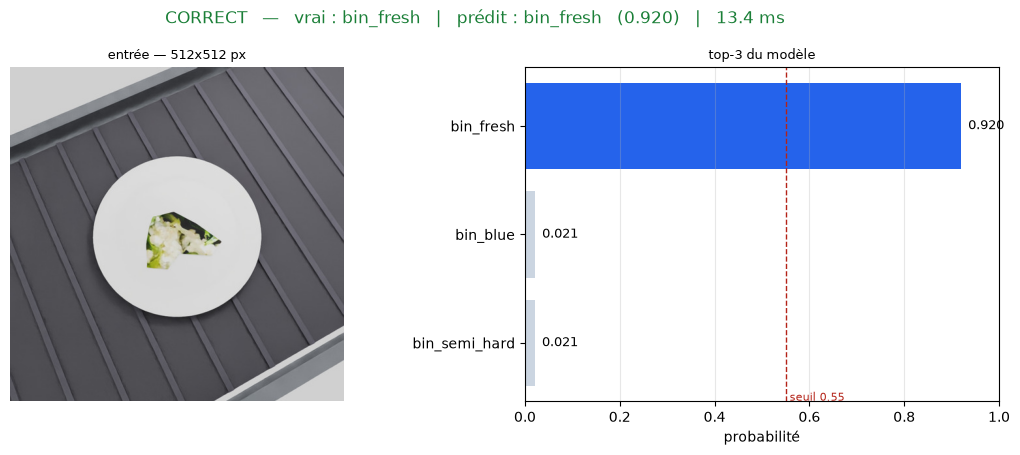

modèle       : sim
pièce source : 208099837fde7a94
type FR      : cottage_cheese
prise de vue : azimut 244°, élévation 77°


In [21]:
MODELE = 'sim'        # bascule sur 'reel' pour comparer

clf = modeles[MODELE]
ligne = random.choice(sim_test)

with Image.open(PROJET / 'data/processed' / ligne['path']) as im:
    im = im.convert('RGB')
    pred = clf.predict(im)
    vignette = im.copy()

vrai = ligne['label']
juste = pred.label == vrai
couleur = '#1a7f37' if juste else ('#b54708' if pred.label == 'unknown' else '#b42318')

fig, (g, d) = plt.subplots(1, 2, figsize=(11, 4.6), gridspec_kw={'width_ratios': [1, 1]})
g.imshow(vignette); g.axis('off')
g.set_title(f"entrée — {vignette.size[0]}x{vignette.size[1]} px", fontsize=9)

noms = [n for n, _ in pred.topk][::-1]
scores = [s for _, s in pred.topk][::-1]
couleurs = ['#2563eb' if n == vrai else '#cbd5e1' for n in noms]
d.barh(noms, scores, color=couleurs)
d.axvline(SEUIL, color='#b42318', ls='--', lw=1)
d.text(SEUIL, -0.45, f' seuil {SEUIL}', color='#b42318', fontsize=8, va='top')
d.set_xlim(0, 1); d.set_xlabel('probabilité'); d.grid(axis='x', alpha=.3)
for i, s in enumerate(scores):
    d.text(s + 0.015, i, f'{s:.3f}', va='center', fontsize=9)
d.set_title('top-3 du modèle', fontsize=9)

verdict = 'CORRECT' if juste else ('ABSTENTION' if pred.label == 'unknown' else 'ERREUR')
fig.suptitle(f"{verdict}   —   vrai : {vrai}   |   prédit : {pred.label}"
             f"   ({pred.confidence:.3f})   |   {pred.latency_ms:.1f} ms",
             color=couleur, fontsize=12)
plt.tight_layout(); plt.show()

print(f"modèle       : {MODELE}")
print(f"pièce source : {ligne['group']}")
print(f"type FR      : {json.loads(ligne['extra'])['fr_label']}")
print(f"prise de vue : azimut {json.loads(ligne['extra'])['azimut']:.0f}°, "
      f"élévation {json.loads(ligne['extra'])['elevation']:.0f}°")

### Les deux modèles sur la même image

Relance pour comparer ce que donnent le modèle entraîné sur photos réelles et celui
entraîné sur rendus, face à une image du domaine cible.

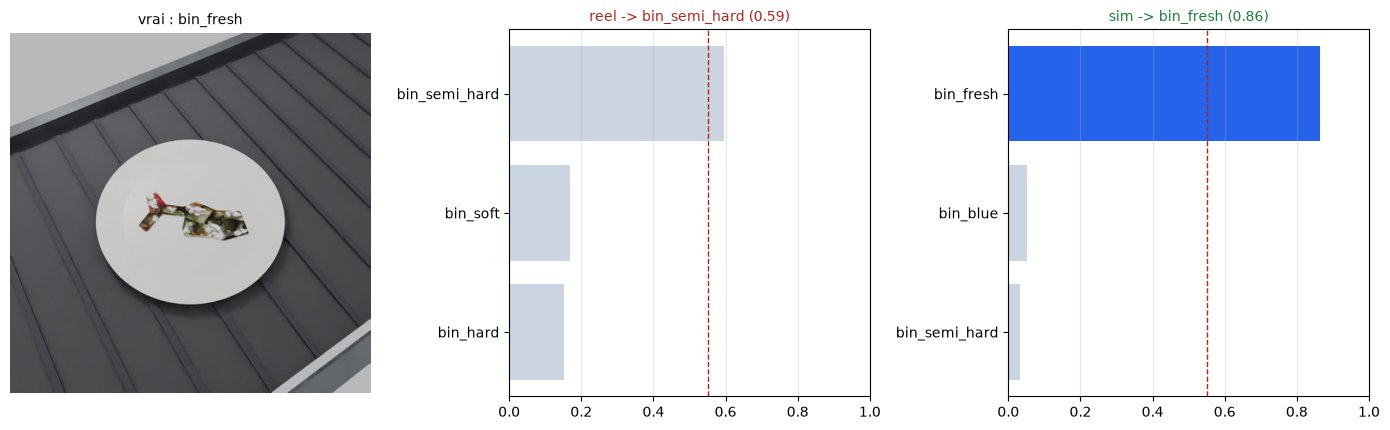

In [22]:
if len(modeles) == 2:
    ligne = random.choice(sim_test)
    with Image.open(PROJET / 'data/processed' / ligne['path']) as im:
        im = im.convert('RGB')
        resultats = {n: m.predict(im) for n, m in modeles.items()}
        vignette = im.copy()

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
    axes[0].imshow(vignette); axes[0].axis('off')
    axes[0].set_title(f"vrai : {ligne['label']}", fontsize=10)
    for ax, (nom, pr) in zip(axes[1:], resultats.items()):
        noms = [n for n, _ in pr.topk][::-1]
        scores = [s for _, s in pr.topk][::-1]
        ax.barh(noms, scores,
                color=['#2563eb' if n == ligne['label'] else '#cbd5e1' for n in noms])
        ax.axvline(SEUIL, color='#b42318', ls='--', lw=1)
        ax.set_xlim(0, 1); ax.grid(axis='x', alpha=.3)
        ok = pr.label == ligne['label']
        ax.set_title(f"{nom} -> {pr.label} ({pr.confidence:.2f})", fontsize=10,
                     color='#1a7f37' if ok else '#b42318')
    plt.tight_layout(); plt.show()
else:
    print('les deux modèles ne sont pas disponibles')

### Inférer sur une image précise du jeu de données

Mets un chemin dans `IMAGE` et relance. Le chemin peut être relatif à
`data/processed/` (comme dans le manifeste) ou absolu. La cellule suivante
imprime une liste de chemins valides à copier-coller.

In [23]:
# Quelques chemins valides, pris dans le jeu de TEST (jamais vus à l'entraînement)
random.seed()
for bac in sorted({r['label'] for r in sim_rows}):
    ex = [r for r in sim_rows if r['label'] == bac and r['split'] == 'test']
    print(f'{bac:16s} {random.choice(ex)["path"]}')
print()
print('photos réelles (non simulées) :')
for bac in sorted({r['bin'] for r in sub})[:2]:
    ex = [r for r in sub if r['bin'] == bac and r['split'] == 'test']
    print(f'{bac:16s} {random.choice(ex)["path"]}')

bin_blue         images/sim_belt/bin_blue/bin_blue__779827de25658533__v3.jpg
bin_fresh        images/sim_belt/bin_fresh/bin_fresh__5907fc9aa8d05061__v3.jpg
bin_hard         images/sim_belt/bin_hard/bin_hard__7bd7821cefd8b88d__v2.jpg
bin_semi_hard    images/sim_belt/bin_semi_hard/bin_semi_hard__177b62710232b86c__v3.jpg
bin_soft         images/sim_belt/bin_soft/bin_soft__942b3d48c224fb32__v2.jpg

photos réelles (non simulées) :
bin_blue         images/food_recognition/blue_mould_cheese/f9e38503ac258b65.jpg
bin_fresh        images/food_recognition/cream_cheese/f1fbcbec304e4efe.jpg


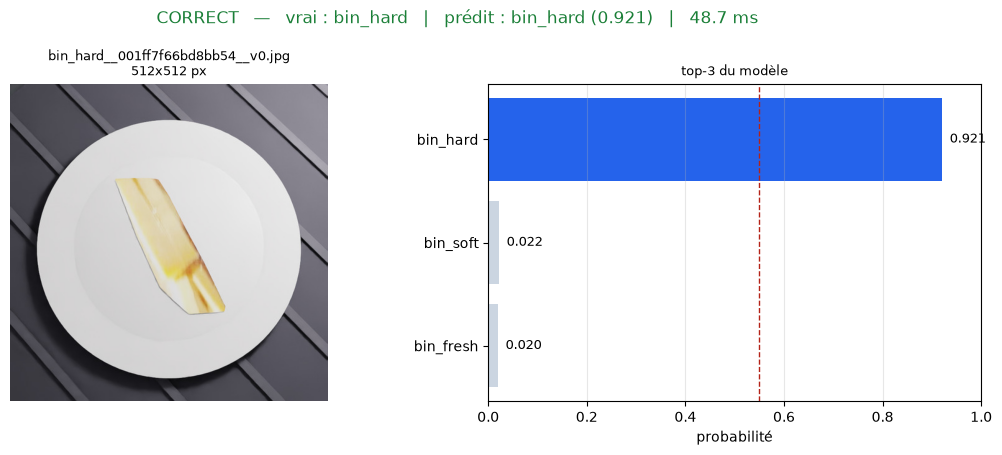

# ce que reçoit le contrôle du bras :
{
  "label": "bin_hard",
  "index": 2,
  "confidence": 0.9211911559104919,
  "topk": [
    [
      "bin_hard",
      0.9211911559104919
    ],
    [
      "bin_soft",
      0.02243952266871929
    ],
    [
      "bin_fresh",
      0.020272420719265938
    ]
  ],
  "latency_ms": 48.698785016313195
}


In [24]:
IMAGE = 'images/sim_belt/bin_hard/bin_hard__001ff7f66bd8bb54__v0.jpg'

# ---------------------------------------------------------------------
chemin = Path(IMAGE)
if not chemin.is_absolute():
    chemin = PROJET / 'data/processed' / IMAGE
assert chemin.exists(), f'introuvable : {chemin}'

# la vraie réponse, si l'image vient d'un des manifestes
rel = str(chemin.relative_to(PROJET / 'data/processed')) if str(chemin).startswith(str(PROJET)) else None
verite = next((r['label'] for r in sim_rows if r['path'] == rel), None) \
      or next((r['bin'] for r in sub if r['path'] == rel), None)

with Image.open(chemin) as im:
    im = im.convert('RGB')
    pred = modeles['sim'].predict(im)
    vignette = im.copy()

fig, (g, d) = plt.subplots(1, 2, figsize=(11, 4.6))
g.imshow(vignette); g.axis('off')
g.set_title(f'{chemin.name}\n{vignette.size[0]}x{vignette.size[1]} px', fontsize=9)

noms = [n for n, _ in pred.topk][::-1]
scores = [s for _, s in pred.topk][::-1]
d.barh(noms, scores, color=['#2563eb' if n == verite else '#cbd5e1' for n in noms])
d.axvline(SEUIL, color='#b42318', ls='--', lw=1)
d.set_xlim(0, 1); d.set_xlabel('probabilité'); d.grid(axis='x', alpha=.3)
for i, s in enumerate(scores):
    d.text(s + 0.015, i, f'{s:.3f}', va='center', fontsize=9)
d.set_title('top-3 du modèle', fontsize=9)

if verite:
    juste = pred.label == verite
    titre = f'{"CORRECT" if juste else "ERREUR"}   —   vrai : {verite}   |   prédit : {pred.label} ({pred.confidence:.3f})'
    couleur = '#1a7f37' if juste else '#b42318'
else:
    titre = f'prédit : {pred.label} ({pred.confidence:.3f})   —   vraie réponse inconnue'
    couleur = '#334155'
fig.suptitle(f'{titre}   |   {pred.latency_ms:.1f} ms', color=couleur, fontsize=12)
plt.tight_layout(); plt.show()

print("# ce que reçoit le contrôle du bras :")
print(json.dumps(pred.as_dict(), indent=2, ensure_ascii=False))

## 8. Le modèle sur une ligne de tri

Une ligne complète montée dans Isaac Sim, **aiguillée par le modèle**. Une pièce arrive
sur le tapis, s'arrête sous la caméra d'inspection, `sim_type13` dit de quel fromage il
s'agit, et le déflecteur de cette classe se lève pour la pousser sur sa voie. Une voie
par classe de sortie : les cinq bacs, plus `REJECT` pour tout statut qui n'est pas `ok`.

Rien n'est scripté — la voie est celle que renvoie `CheeseSorter.predict()` sur l'image
que la caméra vient de prendre. La scène est `sim/sorting_line.py` ; le modèle tourne
côté hôte derrière `sim/sort_server.py`, parce que l'image Isaac Sim n'a ni torch ni
timm. Le poste d'inspection réutilise le tapis, l'assiette et le quad découpé de
`sim/render_belt.py` : la caméra voit donc le domaine sur lequel le modèle a appris.

### La vidéo

<video controls loop width="960" src="/notebook/files/cheese/sim/cheese_sorting.mp4"></video>

*Lecteur vide ?* L'URL ci-dessus est celle que sert la webapp Jupyter. Sur l'hôte, ou si
le lecteur reste blanc, exécute la cellule ci-dessous (`Maj`+`Entrée`) : elle embarque le
fichier directement dans la sortie de la cellule.

In [ ]:
from IPython.display import Video, Markdown, display

VIDEO = PROJECT / 'sim/cheese_sorting.mp4'
if VIDEO.exists():
    # embed=True : la video part dans la sortie de la cellule, donc elle s'affiche
    # aussi bien sur l'hote que dans la webapp, sans dependre du routage des URL
    display(Video(str(VIDEO), embed=True, width=960,
                  html_attributes='controls loop style="border-radius:8px"'))
else:
    display(Markdown(f'`{VIDEO}` absent — relancer `sync_jupyter.sh` sur l\'hote, '
                     'ou refabriquer avec `sim/sorting_line.py` puis `sim/make_video.py`.'))

### Ce qu'elle a trié, pièce par pièce

In [ ]:
run = json.loads((PROJECT / 'sim/cheese_sorting.json').read_text())
print(f"{run['traitees']} pieces inspectees, {run['justes']} dans le bac attendu\n")
for d in run['decisions']:
    dec = d['decision']
    marque = 'ok  ' if d['voie'] == d['verite_voie'] else 'RATE'
    print(f"{marque} {d['label'][:28]:30s} -> {dec['cheese_type']:20s} "
          f"{d['voie']:14s} {dec['bin_confidence']:.3f}  {dec['latency_ms']:.0f} ms")
print('\npar sortie :', run['compteurs'])

> **Les onze pièces sont choisies.** `sim/pick_demo_pieces.py` garde les fromages que le
> modèle traite déjà bien sur les rendus d'entraînement : 11/11 montre la ligne qui
> marche, pas le taux d'erreur du modèle, qui reste à 0.754 sur la décision de bac
> (section 3). Ce que ça montre en revanche : une image d'une scène Isaac Sim vivante
> atteint le modèle et revient en voie de tri en 29–48 ms, et un taboulé finit dans
> `REJECT` plutôt que dans un bac à fromage.

## 9. Le bras range ce que le modèle a décidé

La même ligne, un cran plus loin : la décision de la caméra commande un **Franka FR3**.
Une assiette arrive, le tapis l'indexe sous le poste d'inspection, `sim_type13` nomme le
fromage, et le bras porte l'assiette vers la voie de cette classe.

Deux modèles, deux métiers, aucun ne sait que l'autre existe. Le classifieur rend un bac
et n'a jamais vu de bras. Le bras reçoit **un entier** — jamais une image, jamais une
classe. Le point de rencontre est `sim/pick_line.py` ; la cellule est `sim/pick_cell.py`.

**Ce qui pilote le bras ici est l'automate de référence, pas la politique apprise.**
Le bandeau le dit, en haut à droite. La politique PPO de `sim/train_pick.py` saisit,
lève et porte l'assiette — mais elle n'a pas appris à la poser, et la section 9.1 dit
précisément où elle en est. Les décisions de tri de cette vidéo sont celles du modèle,
les huit ; le bras n'est que l'actionneur.

Trois choses qu'il a fallu apprendre à la cellule, chacune au prix d'un entraînement
entier :

* **Une assiette qu'une pince parallèle peut vraiment tenir.** 180 mm saisis par le bord
  pendent à 90 mm du centre de masse — 0,12 N·m sur deux mors, elle bascule et le
  fromage tombe. À 68 mm la pince l'enjambe et la ligne de prise passe par le centre de
  masse.
* **Une récompense qui paie le progrès, pas l'état.** Porter rapportait ~10 par pas,
  aussi longtemps qu'on voulait ; poser rapportait 80 une fois et arrêtait l'épisode.
  Flâner valait dix fois mieux que réussir, et 29 M de pas ont servi à apprendre
  exactement cela. La récompense est maintenant la variation d'un potentiel, nulle quand
  rien ne se passe.
* **Un bras qui atteint ses propres voies.** L'axe 1 d'un FR3 s'arrête à ±157°, d'où un
  secteur de 46° derrière lui où rien n'est atteignable. Monté face au tapis, ce secteur
  tombait au milieu de l'arc des voies : `bin_soft` et `bin_fresh` étaient hors
  d'atteinte.

### La vidéo

<video controls loop width="960" src="/notebook/files/cheese/sim/cheese_picking.mp4"></video>

*Lecteur vide ?* Comme en section 8 — lance la cellule ci-dessous pour embarquer le
fichier dans la sortie.

In [ ]:
from IPython.display import Video, Markdown, display

BRAS = PROJECT / 'sim/cheese_picking.mp4'
if BRAS.exists():
    display(Video(str(BRAS), embed=True, width=960,
                  html_attributes='controls loop style="border-radius:8px"'))
else:
    display(Markdown(f'`{BRAS}` absent — relancer `sync_jupyter.sh` sur l\'hote, '
                     'ou refabriquer avec `sim/pick_line.py` puis `sim/make_video.py`.'))


### Ce que le bras a fait, pièce par pièce

In [ ]:
bras = json.loads((PROJECT / 'sim/cheese_picking.json').read_text())
print(f"{bras['traitees']} pieces  |  {bras['posees']} assiettes posees  |  "
      f"{bras['justes']} dans le bac attendu  |  pilote : {bras['pilote']}\n")
for r in bras['resultats']:
    marque = 'ok  ' if r.get('juste') else 'RATE'
    print(f"{marque} {r['verite_label'][:26]:28s} -> {r.get('cheese_type', '?'):20s} "
          f"{r['voie']:14s} {r.get('bin_confidence', 0):.3f}  "
          f"{r.get('latency_ms', 0):4.0f} ms  geste : {r.get('issue', '?')}")
print('\npar sortie :', bras['compteurs'])


### 9.1 — Où en est la politique du bras

Lecture honnête de la courbe. **La politique apprend à tenir, pas à poser.**

Tant que le curriculum lui donne des épisodes qui commencent assiette déjà pincée, elle
la garde — jusqu'à 33 % des cellules — et elle la porte vers la voie. Quand ce
curriculum s'éteint (itération 500), la tenue tombe à zéro : elle n'a jamais appris à
prendre une assiette sur le tapis toute seule, et elle n'a pas réussi une seule dépose.

Ce que la journée a acheté, c'est un environnement qui ne ment plus. Une prise qui tient
sans bouger sur 400 pas, des assiettes qui ne sont plus éjectées par un collider mis à
l'échelle, un tapis qui entraîne vraiment, des tampons PhysX dimensionnés pour 1024
cellules au lieu de perdre des contacts en silence, et une récompense qu'on ne peut plus
gagner en ne faisant rien. C'étaient de vrais défauts, et chacun suffisait à rendre
l'apprentissage impossible.

Reste le problème d'exploration que le façonnage n'a pas encore résolu : descendre
l'assiette sur la voie et ouvrir les mors. L'automate de référence y arrive dans la même cellule
— le tableau ci-dessus dit combien de fois — donc la tâche est atteignable ; c'est la
politique qui ne l'a pas trouvée.

In [ ]:
import matplotlib.pyplot as plt

hist = json.loads((PROJECT / 'runs/pick_fr3/results.json').read_text())['historique']
it = [e['iteration'] for e in hist]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].plot(it, [100 * e['part_tenue'] for e in hist], label='assiette tenue')
ax[0].plot(it, [100 * e['reussite'] for e in hist], label='assiette posee')
ax[0].set_xlabel('iteration'); ax[0].set_ylabel('%'); ax[0].legend()
ax[0].set_title('ce que la politique sait faire')
ax[1].plot(it, [e['recompense'] for e in hist], color='tab:green')
ax[1].set_xlabel('iteration'); ax[1].set_ylabel('recompense / pas')
ax[1].set_title('recompense de progres')
for a in ax:
    a.grid(alpha=.3); a.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

print(f"{len(hist)} iterations, {len(hist) * 24 * 1024 / 1e6:.1f} M pas")
print(f"tenue max  : {100 * max(e['part_tenue'] for e in hist):.1f} %")
print(f"posee max  : {100 * max(e['reussite'] for e in hist):.1f} %")


## Annexe — comment cette feuille tourne dans la webapp

Le conteneur `jupyter-notebook` ne monte que `/opt/nvidia/launchpad/jupyter-notebook`
(vu comme `/workspace`). Il ne voit donc pas `/home/nvidia/hpe/cheese`. Deux choses
ont été faites pour que la feuille fonctionne quand même :

**1. Les paquets, installés dans le venv du conteneur depuis l'hôte :**

```bash
docker exec jupyter-notebook /opt/venv/bin/pip install \
    torch torchvision --index-url https://download.pytorch.org/whl/cu124
docker exec jupyter-notebook /opt/venv/bin/pip install \
    timm pillow numpy pandas scikit-learn matplotlib
```

`/opt/venv` est le venv qui fait tourner JupyterLab, donc le kernel `python3` par
défaut de la webapp — rien d'autre à sélectionner. Le conteneur reçoit les deux
H100 via CDI, `torch.cuda.is_available()` y répond `True`.

**2. Le projet, recopié dans la zone partagée :**

```bash
/home/nvidia/hpe/cheese/sync_jupyter.sh      # -> /workspace/cheese, ~2 Go
```

Copie et non montage : les deux répertoires sont sur des systèmes de fichiers
différents, donc pas de lien dur possible.

### Deux limites à garder en tête

- `/workspace/cheese` est un **instantané**. Après un réentraînement, relancer
  `sync_jupyter.sh` sinon la feuille lit d'anciens checkpoints.
- Le `pip install` vit dans le conteneur : il survit à un `docker restart`, mais
  un `docker compose up` qui **recrée** le conteneur l'efface.

Pour supprimer ces deux limites, monter le projet directement dans
`/opt/nvidia/launchpad/docker-compose/docker-compose.yml` :

```yaml
    volumes:
      - /opt/nvidia/launchpad/jupyter-notebook:/workspace
      - /home/nvidia/hpe/cheese:/home/nvidia/hpe/cheese
```
